In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("final_full_datasetGSK3B.csv")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
df.head()

Molecule ChEMBL ID  \
0       CHEMBL293191   
1        CHEMBL63727   
2        CHEMBL67374   
3       CHEMBL109977   
4       CHEMBL322970   

                                                      Smiles  pChEMBL Value  \
0  COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1           5.60   
1                     C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1           7.00   
2  COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1           7.80   
3           COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O           8.10   
4       O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1           7.05   

  Activity                                           canonical_smiles  \
0   Active  COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1   
1   Active                     C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1   
2   Active  COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1   
3   Active           COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O   
4   Active       O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1   

     MolWt    LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  \
0  468.492  4.9882       1.0          7.0   86.45                8.0   
1  315.340  2.6565       1.0          6.0   80.88                4.0   
2  458.526  2.5615       2.0          8.0  109.56                9.0   
3  404.426  1.7482       2.0          5.0  102.32                8.0   
4  359.725  2.4334       3.0          6.0  121.57                4.0   

   NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  \
0      35.0            35.0             9.0        26.0           6.0   
1      24.0            24.0             7.0        17.0           7.0   
2      34.0            34.0            10.0        24.0           8.0   
3      30.0            30.0             8.0        22.0           4.0   
4      25.0            25.0             9.0        16.0           3.0   

   NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  NumTripleBonds  \
0         2.0          1.0      39.0             1.0             0.0   
1         0.0          0.0      27.0             1.0             0.0   
2         2.0          0.0      37.0             2.0             0.0   
3         4.0          0.0      33.0             4.0             0.0   
4         5.0          1.0      27.0             4.0             0.0   

   NumRings  NumAromaticRings  NumAliphaticRings  NumSaturatedRings  \
0       5.0               5.0                0.0                0.0   
1       4.0               4.0                0.0                0.0   
2       4.0               4.0                0.0                0.0   
3       4.0               3.0                1.0                0.0   
4       3.0               2.0                1.0                0.0   

   NumAromaticAtoms  NumAliphaticAtoms  FractionCSP3  morgan_0  morgan_1  \
0              27.0                8.0      0.076923         0         0   
1              21.0                3.0      0.000000         0         0   
2              21.0               13.0      0.208333         0         0   
3              15.0               15.0      0.181818         0         0   
4              12.0               13.0      0.000000         0         0   

   morgan_2  morgan_3  morgan_4  morgan_5  morgan_6  morgan_7  morgan_8  \
0         0         0         0         0         0         0         0   
1         0         0         0         0         0         0         0   
2         0         0         0         0         0         0         1   
3         0         0         0         0         0         0         0   
4         0         0         0         0         0         0         0   

   morgan_9  morgan_10  morgan_11  morgan_12  morgan_13  morgan_14  morgan_15  \
0         0          0          0          0          0          0          0   
1         0          0          0          0          0          0          0   
2         0          0          0          0          0     

In [4]:
df.info()   # Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3256 entries, 0 to 3255
Columns: 5148 entries, Molecule ChEMBL ID to rdk_2047
dtypes: float64(24), int64(5120), object(4)
memory usage: 127.9+ MB


In [5]:
df.shape   # No. of Features and Datapoints

(3256, 5148)

In [6]:
df = df[[c for c in df.columns if (
    'morgan' in c.lower() 
    or not any(fp in c.lower() for fp in ['rdk', 'atompair', 'maccs', 'pubchem'])
)]]

In [7]:
df

Molecule ChEMBL ID  \
0          CHEMBL293191   
1           CHEMBL63727   
2           CHEMBL67374   
3          CHEMBL109977   
4          CHEMBL322970   
...                 ...   
3251      CHEMBL6055928   
3252      CHEMBL6165735   
3253      CHEMBL6011417   
3254      CHEMBL6142264   
3255      CHEMBL6134380   

                                                         Smiles  \
0     COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1   
1                        C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1   
2     COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1   
3              COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O   
4          O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1   
...                                                         ...   
3251       O=C(NCC1CCOCC1)c1n[nH]c2ccc(-c3cncc(CN4CCCC4)c3)cc12   
3252                      CC(C)C(=O)Nc1n[nH]c2cc(-c3cccnc3)sc12   
3253          CC(C)Oc1cncc(-c2ccc3[nH]nc(C(=O)NCC4CCOC4)c3c2)c1   
3254    Cc1ccccc1NC(=O)Nc1cccc(-c2cc3[nH]nc(NC(=O)C(C)C)c3s2)c1   
3255     CC(C)C(=O)Nc1n[nH]c2cc(-c3cccc(NC(=O)Nc4ccccc4)c3)sc12   

      pChEMBL Value Activity  \
0              5.60   Active   
1              7.00   Active   
2              7.80   Active   
3              8.10   Active   
4              7.05   Active   
...             ...      ...   
3251           7.77   Active   
3252           8.51   Active   
3253           7.77   Active   
3254           6.77   Active   
3255           7.13   Active   

                                               canonical_smiles    MolWt  \
0     COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1  468.492   
1                        C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1  315.340   
2     COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1  458.526   
3              COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O  404.426   
4          O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1  359.725   
...                                                         ...      ...   
3251       O=C(NCC1CCOCC1)c1n[nH]c2ccc(-c3cncc(CN4CCCC4)c3)cc12  419.529   
3252                      CC(C)C(=O)Nc1n[nH]c2cc(-c3cccnc3)sc12  286.360   
3253          CC(C)Oc1cncc(-c2ccc3[nH]nc(C(=O)NCC4CCOC4)c3c2)c1  380.448   
3254    Cc1ccccc1NC(=O)Nc1cccc(-c2cc3[nH]nc(NC(=O)C(C)C)c3s2)c1  433.537   
3255     CC(C)C(=O)Nc1n[nH]c2cc(-c3cccc(NC(=O)Nc4ccccc4)c3)sc12  419.510   

         LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  NumAtoms  \
0     4.98820       1.0          7.0   86.45                8.0      35.0   
1     2.65650       1.0          6.0   80.88                4.0      24.0   
2     2.56150       2.0          8.0  109.56                9.0      34.0   
3     1.74820       2.0          5.0  102.32                8.0      30.0   
4     2.43340       3.0          6.0  121.57                4.0      25.0   
...       ...       ...          ...     ...                ...       ...   
3251  3.37710       2.0          5.0   83.14                6.0      31.0   
3252  3.28090       2.0          4.0   70.67                3.0      20.0   
3253  3.17840       2.0          5.0   89.13                6.0      28.0   
3254  5.83832       4.0          4.0   98.91                5.0      31.0   
3255  5.52990       4.0          4.0   98.91                5.0      30.0   

      HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  NumOxygens  \
0               35.0             9.0        26.0           6.0         2.0   
1               24.0             7.0        17.0           7.0         0.0   
2               34.0            10.0        24.0           8.0         2.0   
3               30.0             8.0        22.0           4.0         4.0   
4               25.0             9.0        16.0           3.0         5.0   
...              ...             ...         ...           ...         ...   
3251            31.0             7.0        24.0           5.0         2.0   
3252            20.0        

# eliminating zeros 

In [8]:
# Calculate sum of numeric features only
feature_sum = df.sum(numeric_only=True)

# Find features with sum = 0
zero_features = feature_sum[feature_sum == 0].index

# Remove those features
df = df.drop(columns=zero_features)

print("Removed columnsandronew:", len(zero_features))

Removed columnsandronew: 21


In [9]:
df

Molecule ChEMBL ID  \
0          CHEMBL293191   
1           CHEMBL63727   
2           CHEMBL67374   
3          CHEMBL109977   
4          CHEMBL322970   
...                 ...   
3251      CHEMBL6055928   
3252      CHEMBL6165735   
3253      CHEMBL6011417   
3254      CHEMBL6142264   
3255      CHEMBL6134380   

                                                         Smiles  \
0     COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1   
1                        C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1   
2     COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1   
3              COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O   
4          O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1   
...                                                         ...   
3251       O=C(NCC1CCOCC1)c1n[nH]c2ccc(-c3cncc(CN4CCCC4)c3)cc12   
3252                      CC(C)C(=O)Nc1n[nH]c2cc(-c3cccnc3)sc12   
3253          CC(C)Oc1cncc(-c2ccc3[nH]nc(C(=O)NCC4CCOC4)c3c2)c1   
3254    Cc1ccccc1NC(=O)Nc1cccc(-c2cc3[nH]nc(NC(=O)C(C)C)c3s2)c1   
3255     CC(C)C(=O)Nc1n[nH]c2cc(-c3cccc(NC(=O)Nc4ccccc4)c3)sc12   

      pChEMBL Value Activity  \
0              5.60   Active   
1              7.00   Active   
2              7.80   Active   
3              8.10   Active   
4              7.05   Active   
...             ...      ...   
3251           7.77   Active   
3252           8.51   Active   
3253           7.77   Active   
3254           6.77   Active   
3255           7.13   Active   

                                               canonical_smiles    MolWt  \
0     COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1  468.492   
1                        C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1  315.340   
2     COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1  458.526   
3              COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O  404.426   
4          O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1  359.725   
...                                                         ...      ...   
3251       O=C(NCC1CCOCC1)c1n[nH]c2ccc(-c3cncc(CN4CCCC4)c3)cc12  419.529   
3252                      CC(C)C(=O)Nc1n[nH]c2cc(-c3cccnc3)sc12  286.360   
3253          CC(C)Oc1cncc(-c2ccc3[nH]nc(C(=O)NCC4CCOC4)c3c2)c1  380.448   
3254    Cc1ccccc1NC(=O)Nc1cccc(-c2cc3[nH]nc(NC(=O)C(C)C)c3s2)c1  433.537   
3255     CC(C)C(=O)Nc1n[nH]c2cc(-c3cccc(NC(=O)Nc4ccccc4)c3)sc12  419.510   

         LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  NumAtoms  \
0     4.98820       1.0          7.0   86.45                8.0      35.0   
1     2.65650       1.0          6.0   80.88                4.0      24.0   
2     2.56150       2.0          8.0  109.56                9.0      34.0   
3     1.74820       2.0          5.0  102.32                8.0      30.0   
4     2.43340       3.0          6.0  121.57                4.0      25.0   
...       ...       ...          ...     ...                ...       ...   
3251  3.37710       2.0          5.0   83.14                6.0      31.0   
3252  3.28090       2.0          4.0   70.67                3.0      20.0   
3253  3.17840       2.0          5.0   89.13                6.0      28.0   
3254  5.83832       4.0          4.0   98.91                5.0      31.0   
3255  5.52990       4.0          4.0   98.91                5.0      30.0   

      HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  NumOxygens  \
0               35.0             9.0        26.0           6.0         2.0   
1               24.0             7.0        17.0           7.0         0.0   
2               34.0            10.0        24.0           8.0         2.0   
3               30.0             8.0        22.0           4.0         4.0   
4               25.0             9.0        16.0           3.0         5.0   
...              ...             ...         ...           ...         ...   
3251            31.0             7.0        24.0           5.0         2.0   
3252            20.0        

# missing values 

In [10]:
df.isnull().sum()

Molecule ChEMBL ID    0
Smiles                0
pChEMBL Value         1
Activity              1
canonical_smiles      0
                     ..
morgan_2043           0
morgan_2044           0
morgan_2045           0
morgan_2046           0
morgan_2047           0
Length: 2055, dtype: int64

In [11]:
# Drop rows with missing values
df = df.dropna().reset_index(drop=True)

print("New shape:", df.shape)

New shape: (3255, 2055)


In [12]:
# Check missing values again
print(df.isnull().sum())

Molecule ChEMBL ID    0
Smiles                0
pChEMBL Value         0
Activity              0
canonical_smiles      0
                     ..
morgan_2043           0
morgan_2044           0
morgan_2045           0
morgan_2046           0
morgan_2047           0
Length: 2055, dtype: int64


In [13]:
print(df.shape)

(3255, 2055)


In [14]:
df = df.drop_duplicates(subset = ['Molecule ChEMBL ID', 'canonical_smiles'])

In [15]:
df.drop(['Molecule ChEMBL ID', 'canonical_smiles'], axis = 1, inplace = True)

In [16]:
df

Smiles  \
0     COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1   
1                        C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1   
2     COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1   
3              COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O   
4          O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1   
...                                                         ...   
3250       O=C(NCC1CCOCC1)c1n[nH]c2ccc(-c3cncc(CN4CCCC4)c3)cc12   
3251                      CC(C)C(=O)Nc1n[nH]c2cc(-c3cccnc3)sc12   
3252          CC(C)Oc1cncc(-c2ccc3[nH]nc(C(=O)NCC4CCOC4)c3c2)c1   
3253    Cc1ccccc1NC(=O)Nc1cccc(-c2cc3[nH]nc(NC(=O)C(C)C)c3s2)c1   
3254     CC(C)C(=O)Nc1n[nH]c2cc(-c3cccc(NC(=O)Nc4ccccc4)c3)sc12   

      pChEMBL Value Activity    MolWt     LogP  H_Donors  H_Acceptors    TPSA  \
0              5.60   Active  468.492  4.98820       1.0          7.0   86.45   
1              7.00   Active  315.340  2.65650       1.0          6.0   80.88   
2              7.80   Active  458.526  2.56150       2.0          8.0  109.56   
3              8.10   Active  404.426  1.74820       2.0          5.0  102.32   
4              7.05   Active  359.725  2.43340       3.0          6.0  121.57   
...             ...      ...      ...      ...       ...          ...     ...   
3250           7.77   Active  419.529  3.37710       2.0          5.0   83.14   
3251           8.51   Active  286.360  3.28090       2.0          4.0   70.67   
3252           7.77   Active  380.448  3.17840       2.0          5.0   89.13   
3253           6.77   Active  433.537  5.83832       4.0          4.0   98.91   
3254           7.13   Active  419.510  5.52990       4.0          4.0   98.91   

      NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  \
0                   8.0      35.0            35.0             9.0        26.0   
1                   4.0      24.0            24.0             7.0        17.0   
2                   9.0      34.0            34.0            10.0        24.0   
3                   8.0      30.0            30.0             8.0        22.0   
4                   4.0      25.0            25.0             9.0        16.0   
...                 ...       ...             ...             ...         ...   
3250                6.0      31.0            31.0             7.0        24.0   
3251                3.0      20.0            20.0             6.0        14.0   
3252                6.0      28.0            28.0             7.0        21.0   
3253                5.0      31.0            31.0             8.0        23.0   
3254                5.0      30.0            30.0             8.0        22.0   

      NumNitrogens  NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  \
0              6.0         2.0          1.0      39.0             1.0   
1              7.0         0.0          0.0      27.0             1.0   
2              8.0         2.0          0.0      37.0             2.0   
3              4.0         4.0          0.0      33.0             4.0   
4              3.0         5.0          1.0      27.0             4.0   
...            ...         ...          ...       ...             ...   
3250           5.0         2.0          0.0      35.0             1.0   
3251           4.0         1.0          0.0      22.0             1.0   
3252           4.0         3.0          0.0      31.0             1.0   
3253           5.0         2.0          0.0      34.0             2.0   
3254           5.0         2.0          0.0      33.0             2.0   

      NumTripleBonds  NumRings  NumAromaticRings  NumAliphaticRings  \
0                0.0       5.0               5.0                0.0   
1                0.0       4.0               4.0                0.0   
2                0.0       4.0               4.0                0.0   
3                0.0       4.0               3.0                1.0   
4                0.0       3.0               2.0                1.0   
...

# label encoding

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Activity"] = le.fit_transform(df["Activity"])

In [19]:
df['Activity'].value_counts()

Activity
0    2950
1     305
Name: count, dtype: int64

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

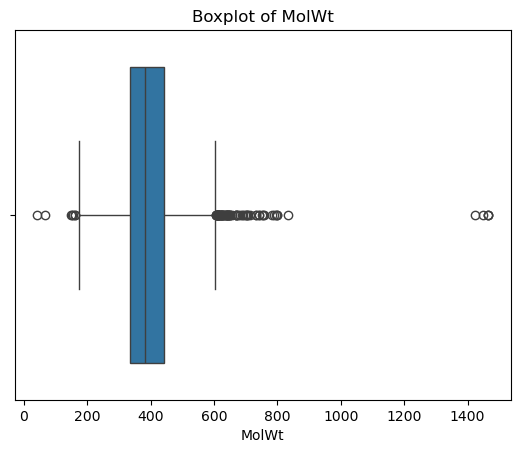

In [21]:
sns.boxplot (x =df ['MolWt'])
plt.title ("Boxplot of MolWt")
plt.show()

In [22]:
numeric_cols = ["MolWt", "LogP", "H_Acceptors","H_Donors", "TPSA","NumRotatableBonds"]

Outliers ={}
for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        
        IQR = Q3 - Q1
         
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR 
        
        Outliers[col]=df[(df[col]<lower)| (df[col]>upper)]
        
        print (f"{col} : {len(Outliers [col])} outlier detected")

MolWt : 82 outlier detected
LogP : 60 outlier detected
H_Acceptors : 74 outlier detected
H_Donors : 173 outlier detected
TPSA : 118 outlier detected
NumRotatableBonds : 141 outlier detected


# removing outliers

In [23]:
df = df[(df[col] >= lower) & (df[col] <= upper)]
df

Smiles  \
0     COc1cccc(-n2ncc3c(N/N=C/c4ccc(OCc5ccc(F)cc5)cc4)ncnc32)c1   
1                        C(=N/Nc1ncnc2c1cnn2-c1ccccc1)\c1ccncc1   
2     COc1cccc(-n2ncc3c(N/N=C/c4ccc(C(=O)NCCN(C)C)cc4)ncnc32)c1   
3              COc1ccccc1C1=C(c2cn(CCCNC=O)c3ncccc23)C(=O)NC1=O   
4          O=C1NC(=O)C(c2ccccc2[N+](=O)[O-])=C1Nc1ccc(O)c(Cl)c1   
...                                                         ...   
3250       O=C(NCC1CCOCC1)c1n[nH]c2ccc(-c3cncc(CN4CCCC4)c3)cc12   
3251                      CC(C)C(=O)Nc1n[nH]c2cc(-c3cccnc3)sc12   
3252          CC(C)Oc1cncc(-c2ccc3[nH]nc(C(=O)NCC4CCOC4)c3c2)c1   
3253    Cc1ccccc1NC(=O)Nc1cccc(-c2cc3[nH]nc(NC(=O)C(C)C)c3s2)c1   
3254     CC(C)C(=O)Nc1n[nH]c2cc(-c3cccc(NC(=O)Nc4ccccc4)c3)sc12   

      pChEMBL Value  Activity    MolWt     LogP  H_Donors  H_Acceptors  \
0              5.60         0  468.492  4.98820       1.0          7.0   
1              7.00         0  315.340  2.65650       1.0          6.0   
2              7.80         0  458.526  2.56150       2.0          8.0   
3              8.10         0  404.426  1.74820       2.0          5.0   
4              7.05         0  359.725  2.43340       3.0          6.0   
...             ...       ...      ...      ...       ...          ...   
3250           7.77         0  419.529  3.37710       2.0          5.0   
3251           8.51         0  286.360  3.28090       2.0          4.0   
3252           7.77         0  380.448  3.17840       2.0          5.0   
3253           6.77         0  433.537  5.83832       4.0          4.0   
3254           7.13         0  419.510  5.52990       4.0          4.0   

        TPSA  NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  \
0      86.45                8.0      35.0            35.0             9.0   
1      80.88                4.0      24.0            24.0             7.0   
2     109.56                9.0      34.0            34.0            10.0   
3     102.32                8.0      30.0            30.0             8.0   
4     121.57                4.0      25.0            25.0             9.0   
...      ...                ...       ...             ...             ...   
3250   83.14                6.0      31.0            31.0             7.0   
3251   70.67                3.0      20.0            20.0             6.0   
3252   89.13                6.0      28.0            28.0             7.0   
3253   98.91                5.0      31.0            31.0             8.0   
3254   98.91                5.0      30.0            30.0             8.0   

      NumCarbons  NumNitrogens  NumOxygens  NumHalogens  NumBonds  \
0           26.0           6.0         2.0          1.0      39.0   
1           17.0           7.0         0.0          0.0      27.0   
2           24.0           8.0         2.0          0.0      37.0   
3           22.0           4.0         4.0          0.0      33.0   
4           16.0           3.0         5.0          1.0      27.0   
...          ...           ...         ...          ...       ...   
3250        24.0           5.0         2.0          0.0      35.0   
3251        14.0           4.0         1.0          0.0      22.0   
3252        21.0           4.0         3.0          0.0      31.0   
3253        23.0           5.0         2.0          0.0      34.0   
3254        22.0           5.0         2.0          0.0      33.0   

      NumDoubleBonds  NumTripleBonds  NumRings  NumAromaticRings  \
0                1.0             0.0       5.0               5.0   
1                1.0             0.0       4.0               4.0   
2                2.0             0.0       4.0               4.0   
3                4.0             0.0       4.0               3.0   
4                4.0             0.0       3.0               2.0   
...              ...             ...       ...               ...   
3250             1.0             0.0       5.0               3.0   
3251             1.0             0.0       3.0               3.0 

# removing corelated factors

In [24]:
import numpy as np

# Columns that must NOT be used for correlation-based deletion
exclude_columns = [
    "Activity",
    "pChEMBL Value"
]

# Select only numeric columns except target and pChEMBL
numeric_df = df.select_dtypes(include=["number"]).drop(
    columns=exclude_columns,
    errors="ignore"
)

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Store correlated features
correlated_features = set()

# Check only the upper triangle of correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) > 0.80:

            colname = correlation_matrix.columns[i]

            correlated_features.add(colname)


# Display results
print("Number of correlated features to remove:",
       len(correlated_features))

print("\nCorrelated features:")
print(correlated_features)

Number of correlated features to remove: 139

Correlated features:
{'morgan_1929', 'morgan_1441', 'morgan_1157', 'NumRings', 'morgan_1654', 'morgan_1631', 'morgan_1316', 'morgan_391', 'morgan_1132', 'morgan_1685', 'morgan_1167', 'morgan_891', 'morgan_1381', 'morgan_1748', 'morgan_949', 'morgan_1863', 'morgan_1280', 'morgan_1284', 'morgan_507', 'morgan_885', 'morgan_785', 'morgan_1884', 'morgan_1667', 'morgan_398', 'morgan_1064', 'morgan_707', 'morgan_1520', 'morgan_1594', 'morgan_2029', 'morgan_863', 'morgan_1220', 'morgan_701', 'morgan_1844', 'morgan_463', 'morgan_595', 'NumHeteroatoms', 'morgan_1858', 'morgan_1345', 'morgan_1633', 'morgan_1261', 'morgan_1795', 'morgan_1808', 'morgan_660', 'morgan_1551', 'morgan_1881', 'morgan_1986', 'morgan_494', 'morgan_1556', 'morgan_357', 'morgan_1867', 'morgan_1373', 'morgan_898', 'morgan_1821', 'morgan_438', 'morgan_674', 'morgan_1806', 'morgan_1801', 'morgan_1712', 'morgan_1752', 'morgan_1928', 'morgan_909', 'morgan_1963', 'morgan_1767', 'morga

In [25]:
df.drop(
    columns=list(correlated_features),
    inplace=True
)

print("Correlated features removed successfully.")

print("New dataset shape:")
print(df.shape)

Correlated features removed successfully.
New dataset shape:
(3114, 1914)


C:\Users\sahan\AppData\Local\Temp\ipykernel_9108\1558483522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(


# train and split 

In [26]:
print(df.groupby("Activity")["pChEMBL Value"].agg(["min", "max", "count"]))

           min    max  count
Activity                    
0         5.00  10.89   2836
1         3.38   4.99    278


In [27]:
print(df["Activity"].value_counts())

Activity
0    2836
1     278
Name: count, dtype: int64


In [28]:
df["Activity"]

0       0
1       0
2       0
3       0
4       0
       ..
3250    0
3251    0
3252    0
3253    0
3254    0
Name: Activity, Length: 3114, dtype: int64

In [29]:
# Correct the activity labels

df["Activity"] = 1 - df["Activity"]

print(df["Activity"].value_counts())

Activity
1    2836
0     278
Name: count, dtype: int64


C:\Users\sahan\AppData\Local\Temp\ipykernel_9108\959254278.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Activity"] = 1 - df["Activity"]


In [30]:
print(
    df.groupby("Activity")["pChEMBL Value"]
      .agg(["min", "max", "count"])
)

           min    max  count
Activity                    
0         3.38   4.99    278
1         5.00  10.89   2836


In [31]:
df = df.copy()

In [32]:
# Features and target

X = df.drop(
    columns=["Activity", "pChEMBL Value"],
    errors="ignore"
)

y = df["Activity"]

# Keep only numerical ML features
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (3114, 1911)
y shape: (3114,)

Class distribution:
Activity
1    2836
0     278
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (2491, 1911)
X_test shape: (623, 1911)

Training class distribution:
Activity
1    2269
0     222
Name: count, dtype: int64

Test class distribution:
Activity
1    567
0     56
Name: count, dtype: int64


# smote analysis

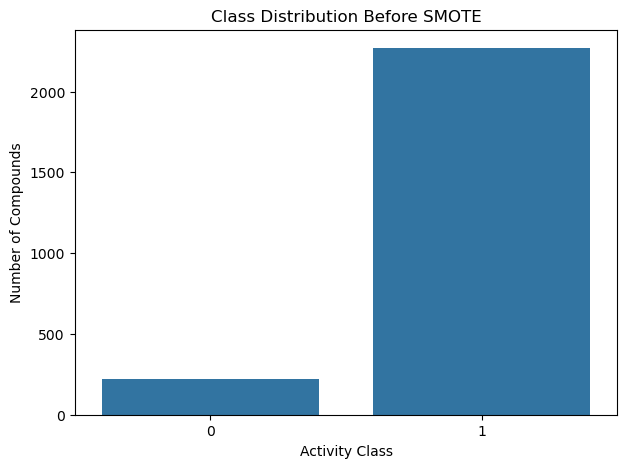

In [34]:
# Class distribution before SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution Before SMOTE")

plt.show()

In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Activity
1    2269
0     222
Name: count, dtype: int64

After SMOTE:
Activity
1    2269
0    2269
Name: count, dtype: int64


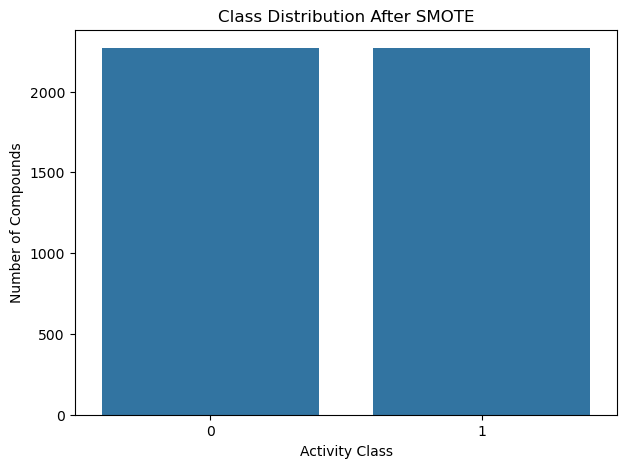

In [36]:
# Class distribution after SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution After SMOTE")

plt.show()

# logistic regression 

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [38]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

LR = LogisticRegression(max_iter=1000)

LR.fit(X_train_sm, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
LR_predict = LR.predict(X_test_scaled)

In [40]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, LR_predict))

print(classification_report(
    y_test,
    LR_predict,
    target_names=["Inactive", "Active"],
    digits=4
))

Accuracy_score = 0.913322632423756
              precision    recall  f1-score   support

    Inactive     0.5217    0.4286    0.4706        56
      Active     0.9445    0.9612    0.9528       567

    accuracy                         0.9133       623
   macro avg     0.7331    0.6949    0.7117       623
weighted avg     0.9065    0.9133    0.9095       623



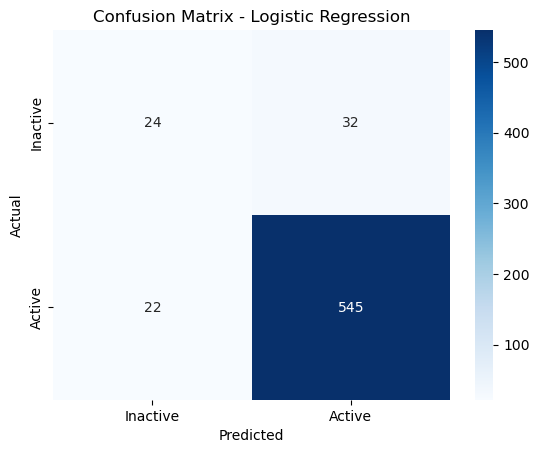

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, LR_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

LR ROC AUC = 0.781


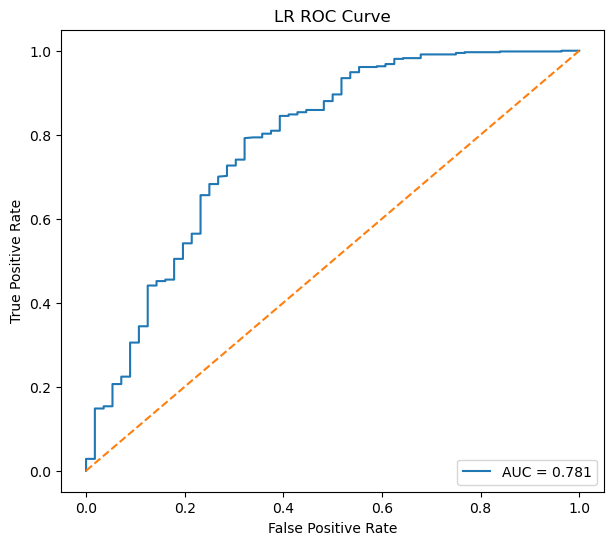

In [42]:
from sklearn.metrics import roc_curve, auc

LR_prob = LR.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    LR_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LR ROC Curve")

plt.legend(loc="lower right")

print("LR ROC AUC = %.3f" % roc_auc)

plt.show()

# decision tree

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
DT = DecisionTreeClassifier(
    random_state=42
)

DT.fit(
    X_train_smote,
    y_train_smote
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
DT_predict = DT.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, DT_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        DT_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.9101123595505618

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.5000    0.3929    0.4400        56
      Active     0.9413    0.9612    0.9511       567

    accuracy                         0.9101       623
   macro avg     0.7206    0.6770    0.6956       623
weighted avg     0.9016    0.9101    0.9052       623



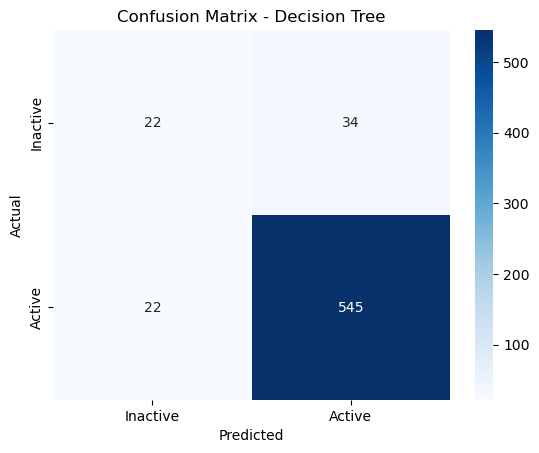

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    DT_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Decision Tree ROC AUC = 0.677


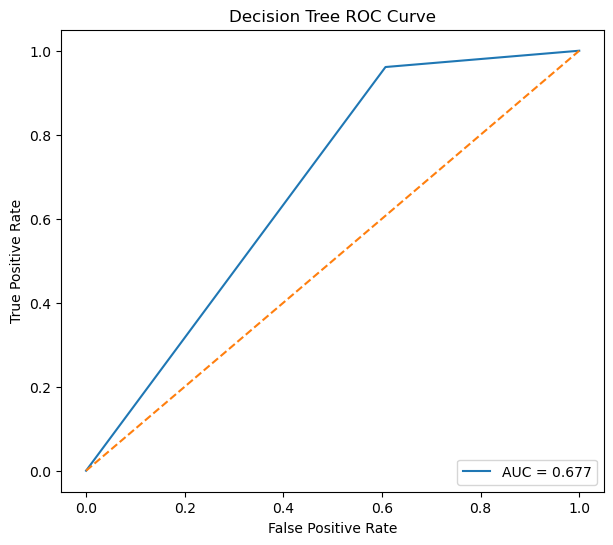

In [48]:
from sklearn.metrics import roc_curve, auc

DT_prob = DT.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    DT_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend(loc="lower right")

print("Decision Tree ROC AUC = %.3f" % roc_auc)

plt.show()

# random forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
RF = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

RF.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
RF_predict = RF.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, RF_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        RF_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.9261637239165329

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6471    0.3929    0.4889        56
      Active     0.9423    0.9788    0.9602       567

    accuracy                         0.9262       623
   macro avg     0.7947    0.6858    0.7245       623
weighted avg     0.9157    0.9262    0.9178       623



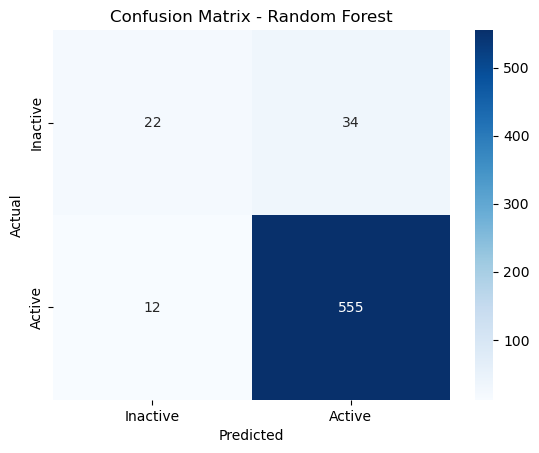

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    RF_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

Random Forest ROC AUC = 0.902


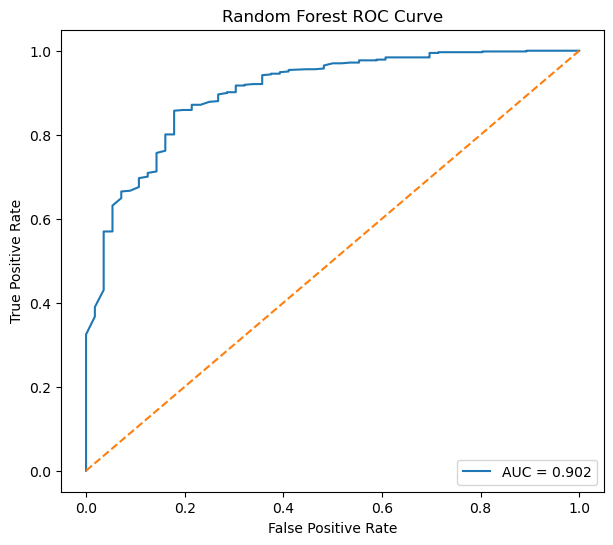

In [54]:
from sklearn.metrics import roc_curve, auc

RF_prob = RF.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    RF_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend(loc="lower right")

print("Random Forest ROC AUC = %.3f" % roc_auc)

plt.show()

# XGBOOST

In [55]:
from xgboost import XGBClassifier

In [56]:
XGB = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

XGB.fit(
    X_train_smote,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [57]:
XGB_predict = XGB.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, XGB_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        XGB_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.9229534510433387

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6053    0.4107    0.4894        56
      Active     0.9436    0.9735    0.9583       567

    accuracy                         0.9230       623
   macro avg     0.7744    0.6921    0.7238       623
weighted avg     0.9132    0.9230    0.9162       623



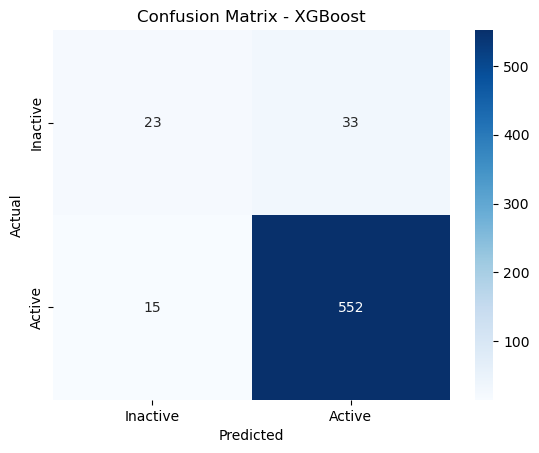

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    XGB_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

XGBoost ROC AUC = 0.878


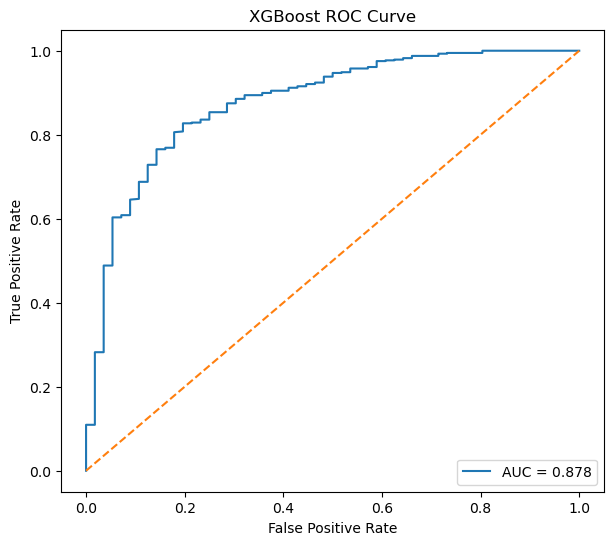

In [60]:
from sklearn.metrics import roc_curve, auc

XGB_prob = XGB.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    XGB_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend(loc="lower right")

print("XGBoost ROC AUC = %.3f" % roc_auc)

plt.show()

# support vector machine

In [61]:
from sklearn.svm import SVC

In [62]:
SVM = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

SVM.fit(
    X_train_sm,
    y_train_smote
)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [63]:
SVM_predict = SVM.predict(X_test_scaled)

In [64]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, SVM_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        SVM_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.913322632423756

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.5500    0.1964    0.2895        56
      Active     0.9254    0.9841    0.9538       567

    accuracy                         0.9133       623
   macro avg     0.7377    0.5903    0.6217       623
weighted avg     0.8916    0.9133    0.8941       623



SVM ROC AUC = 0.825


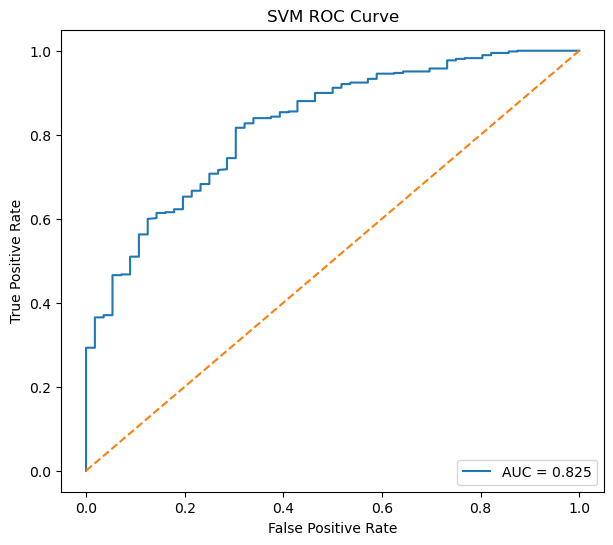

In [65]:
from sklearn.metrics import roc_curve, auc

SVM_prob = SVM.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    SVM_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")

plt.legend(loc="lower right")

print("SVM ROC AUC = %.3f" % roc_auc)

plt.show()

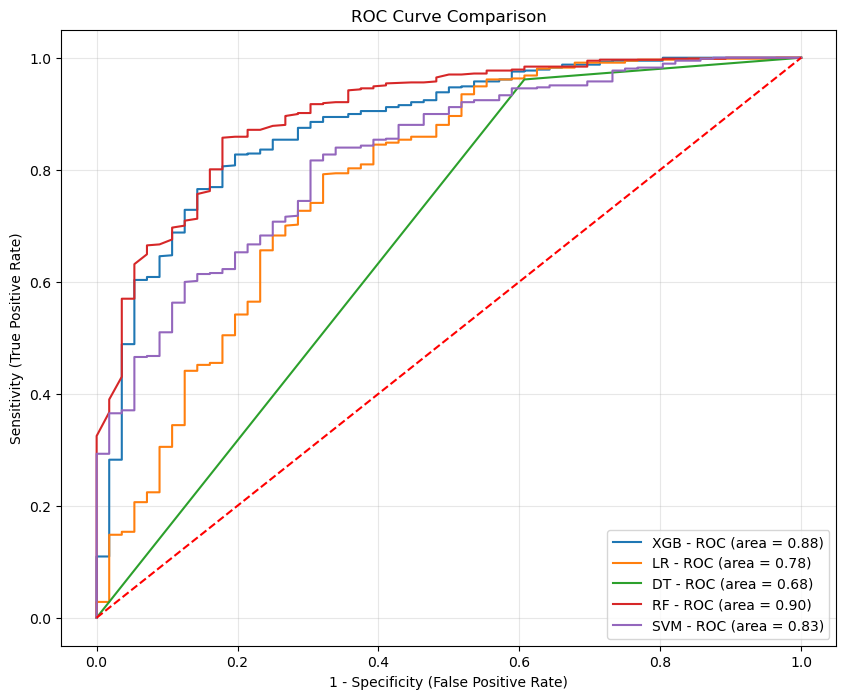

Logistic Regression AUC: 0.781
Decision Tree AUC: 0.677
Random Forest AUC: 0.902
XGBoost AUC: 0.878
SVM AUC: 0.825


In [66]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions for each model
LR_prob = LR.predict_proba(X_test_scaled)[:, 1]
DT_prob = DT.predict_proba(X_test)[:, 1]
RF_prob = RF.predict_proba(X_test)[:, 1]
XGB_prob = XGB.predict_proba(X_test)[:, 1]
SVM_prob = SVM.predict_proba(X_test_scaled)[:, 1]


# Calculate ROC curves
fpr_LR, tpr_LR, _ = roc_curve(y_test, LR_prob)
fpr_DT, tpr_DT, _ = roc_curve(y_test, DT_prob)
fpr_RF, tpr_RF, _ = roc_curve(y_test, RF_prob)
fpr_XGB, tpr_XGB, _ = roc_curve(y_test, XGB_prob)
fpr_SVM, tpr_SVM, _ = roc_curve(y_test, SVM_prob)


# Calculate AUC
auc_LR = auc(fpr_LR, tpr_LR)
auc_DT = auc(fpr_DT, tpr_DT)
auc_RF = auc(fpr_RF, tpr_RF)
auc_XGB = auc(fpr_XGB, tpr_XGB)
auc_SVM = auc(fpr_SVM, tpr_SVM)


# Plot ROC curves
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_XGB, tpr_XGB,
    label="XGB - ROC (area = %.2f)" % auc_XGB
)

plt.plot(
     fpr_LR, tpr_LR,
    label="LR - ROC (area = %.2f)" % auc_LR
)

plt.plot(
    fpr_DT, tpr_DT,
    label="DT - ROC (area = %.2f)" % auc_DT
)

plt.plot(
    fpr_RF, tpr_RF,
    label="RF - ROC (area = %.2f)" % auc_RF
)

plt.plot(
    fpr_SVM, tpr_SVM,
    label="SVM - ROC (area = %.2f)" % auc_SVM
)


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    "r--"
)


plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)
plt.show()


# Print AUC values
print("Logistic Regression AUC:", round(auc_LR, 3))
print("Decision Tree AUC:", round(auc_DT, 3))
print("Random Forest AUC:", round(auc_RF, 3))
print("XGBoost AUC:", round(auc_XGB, 3))
print("SVM AUC:", round(auc_SVM, 3))

In [67]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# SMOTE + Random Forest
rfecv_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", rf_model)
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RFECV
rfecv = RFECV(
    estimator=rfecv_pipeline,
    step=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    min_features_to_select=10,
    importance_getter="named_steps.rf.feature_importances_"
)

# Run RFECV ONLY on training data
rfecv.fit(X_train, y_train)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 561


In [69]:
selected_features = X_train.columns[rfecv.support_]

selected_features_df = pd.DataFrame({
    "feature": selected_features
})

selected_features_df.to_csv(
    "rfecv_selected_featuresGSK3B.csv",
    index=False
)

print("Selected features saved:", len(selected_features))

Selected features saved: 561


In [77]:
import joblib
import pandas as pd

# 1. Get the 561 selected features
selected_features = X_train.columns[rfecv.support_].tolist()

print("Selected GSK3B features:", len(selected_features))

# 2. Save the selected feature names
pd.DataFrame({
    "feature": selected_features
}).to_csv(
    "rfecv_selected_featuresGSK3B.csv",
    index=False
)

# 3. Save the fitted estimator from RFECV
gsk3b_rf = rfecv.estimator_

joblib.dump(
    gsk3b_rf,
    "GSK3B_RFECV_model.pkl"
)

print("✅ 561 features saved")
print("✅ GSK3B RF model saved")
print("Model expects:", gsk3b_rf.n_features_in_, "features")

Selected GSK3B features: 561
✅ 561 features saved
✅ GSK3B RF model saved
Model expects: 561 features


In [79]:
import pandas as pd

# ============================================
# GSK3B: 561 selected features → prediction
# ============================================

# 1. Load external compounds
external_df = pd.read_csv("atompair_addedBrain.csv")

# 2. Load GSK3B selected features
selected_df = pd.read_csv(
    "rfecv_selected_featuresGSK3B.csv"
)

selected_features = selected_df["feature"].tolist()

print("Selected GSK3B features:", len(selected_features))

# 3. Create external matrix using ONLY 561 features
X_external_GSK3B = external_df[selected_features]

print("External GSK3B matrix:", X_external_GSK3B.shape)

# 4. Predict
gsk3b_prediction = gsk3b_rf.predict(
    X_external_GSK3B
)

gsk3b_probability = gsk3b_rf.predict_proba(
    X_external_GSK3B
)[:, 1]

print("✅ GSK3B prediction completed")
print("Number of compounds:", len(gsk3b_prediction))

Selected GSK3B features: 561
External GSK3B matrix: (77, 561)


C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


✅ GSK3B prediction completed
Number of compounds: 77


In [81]:
# ============================================
# GSK3B - TOP 20 BY PREDICTED PROBABILITY
# ============================================

# Copy external dataset
gsk3b_results = external_df.copy()

# Add prediction and probability
gsk3b_results["Prediction"] = gsk3b_prediction
gsk3b_results["Probability"] = gsk3b_probability

# Sort highest probability first
gsk3b_results = gsk3b_results.sort_values(
    by="Probability",
    ascending=False
).reset_index(drop=True)

# Take Top 20
top20_GSK3B = gsk3b_results.head(20).copy()

# Add Rank
top20_GSK3B.insert(
    0,
    "Rank",
    range(1, 21)
)

print("✅ GSK3B TOP 20 HITS:", len(top20_GSK3B))

display(
    top20_GSK3B[
        ["Rank", "smiles", "Prediction", "Probability"]
    ]
)

✅ GSK3B TOP 20 HITS: 20


,Rank,smiles,Prediction,Probability
0,1,CCCCNCc1cc(=O)oc2cc(O)ccc12,1,0.840000
1,2,OCCCOc1cccc(CN2CCCCC2O)c1,1,0.815000
2,3,Cc1cccc(C)c1NC(=O)C1CCCCN1C,1,0.811667
3,4,Cc1cccc(C)c1NC(=O)C1CCCCN1C,1,0.811667
4,5,COc1cc(NC(C)CCCN)c2ncccc2c1,1,0.770000
5,6,COc1cc(NC(C)CCCN)c2ncccc2c1,1,0.770000
6,7,CC(=O)c1cc2cccc(OCC(O)CNC(C)C)c2o1,1,0.760000
7,8,CC(=O)c1cc2cccc(OCC(O)CNC(C)C)c2o1,1,0.760000
8,9,CCCCNCc1cc(=O)oc2cc(OC)ccc12,1,0.750000
9,10,CN(C)CCOC(=O)C(c1ccccc1)C1(O)CCCC1,1,0.741667


In [82]:
# Save complete GSK3B Top 20 results

top20_GSK3B.to_excel(
    "TOP20_GSK3B_Hits_Final.xlsx",
    index=False,
    engine="openpyxl"
)

print("✅ GSK3B TOP 20 SAVED")
print("Rows:", len(top20_GSK3B))
print("Columns:", len(top20_GSK3B.columns))
print("File: TOP20_GSK3B_Hits_Final.xlsx")

✅ GSK3B TOP 20 SAVED
Rows: 20
Columns: 3100
File: TOP20_GSK3B_Hits_Final.xlsx


In [83]:
# ============================================
# FINAL TOP 20 UNIQUE GSK3B HITS
# ============================================

# Create results for all 77 compounds
gsk3b_results = external_df.copy()

gsk3b_results["Prediction"] = gsk3b_prediction
gsk3b_results["Probability"] = gsk3b_probability

# Highest probability first
gsk3b_results = gsk3b_results.sort_values(
    by="Probability",
    ascending=False
).reset_index(drop=True)

# Remove EXACT duplicate SMILES
gsk3b_unique = gsk3b_results.drop_duplicates(
    subset="smiles",
    keep="first"
).reset_index(drop=True)

# Take the first 20 UNIQUE highest-scoring compounds
top20_GSK3B = gsk3b_unique.head(20).copy()

# Add rank
top20_GSK3B.insert(
    0,
    "Rank",
    range(1, len(top20_GSK3B) + 1)
)

print("Original compounds:", len(gsk3b_results))
print("Unique compounds:", len(gsk3b_unique))
print("FINAL TOP 20:", len(top20_GSK3B))

display(
    top20_GSK3B[
        ["Rank", "smiles", "Prediction", "Probability"]
    ]
)

Original compounds: 77
Unique compounds: 56
FINAL TOP 20: 20


,Rank,smiles,Prediction,Probability
0,1,CCCCNCc1cc(=O)oc2cc(O)ccc12,1,0.840000
1,2,OCCCOc1cccc(CN2CCCCC2O)c1,1,0.815000
2,3,Cc1cccc(C)c1NC(=O)C1CCCCN1C,1,0.811667
3,4,COc1cc(NC(C)CCCN)c2ncccc2c1,1,0.770000
4,5,CC(=O)c1cc2cccc(OCC(O)CNC(C)C)c2o1,1,0.760000
5,6,CCCCNCc1cc(=O)oc2cc(OC)ccc12,1,0.750000
6,7,CN(C)CCOC(=O)C(c1ccccc1)C1(O)CCCC1,1,0.741667
7,8,CCNCc1cc(=O)oc2cc(OC)ccc12,1,0.740000
8,9,COc1cc2c(cc1OC)C(=O)C(CC1CCNCC1)C2,1,0.730000
9,10,CN1[C@@H]2CC[C@H]1CC(OC(=O)[C@H](O)Cc1ccccc1)C2,1,0.726667


In [84]:
top20_GSK3B.to_excel(
    "TOP20_GSK3B_Hits_Final.xlsx",
    index=False,
    engine="openpyxl"
)

print("✅ FINAL TOP 20 UNIQUE GSK3B HITS SAVED")

✅ FINAL TOP 20 UNIQUE GSK3B HITS SAVED
